In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
sklearn.set_config(enable_metadata_routing=True)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    make_scorer,
    auc,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

import optuna
from optuna_integration.sklearn import OptunaSearchCV
from optuna.distributions import FloatDistribution, IntDistribution

from xgboost import XGBClassifier

In [2]:
RANDOM_STATE = 42
# target variable
TARGET = 'Traffic'
TO_DROP = ['Target', 'Traffic', 'StartTime', 'LastTime', 'SrcAddr', 'DstAddr', 'sIpId', 'dIpId']

df = pd.read_csv('../data/wustl_iiot_2021.csv')

df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df[TARGET]
)

In [3]:
encoder = LabelEncoder()

df_train[TARGET] = encoder.fit_transform(df_train[TARGET])
df_test[TARGET] = encoder.transform(df_test[TARGET])

X_train = df_train.drop(columns=TO_DROP)
y_train = df_train[TARGET]

X_test = df_test.drop(columns=TO_DROP)
y_test = df_test[TARGET]

In [4]:
# 0 is backdoor, 1 is CommInj, ...
encoder.classes_

array(['Backdoor', 'CommInj', 'DoS', 'Reconn', 'normal'], dtype=object)

In [5]:
# compute class weights for imbalanced dataset
unique_classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

class_weights_dict = dict(zip(unique_classes, weights))

In [6]:
class_weights_dict

{np.int64(0): np.float64(1124.2011764705883),
 np.int64(1): np.float64(923.2570048309178),
 np.int64(2): np.float64(3.0507981610369708),
 np.int64(3): np.float64(28.99183859223301),
 np.int64(4): np.float64(0.2157147404278758)}

In [7]:
# set weights for each instance according to class imbalance
w_train = y_train.map(class_weights_dict)
w_test = y_test.map(class_weights_dict)

### Model tuning

In [8]:
# define custom scorer
def multiclass_average_precision(y_true, y_proba, sample_weight=None):
    y_true_binary = label_binarize(
        y_true,
        classes=np.arange(len(encoder.classes_))
    )

    return average_precision_score(
        y_true_binary,
        y_proba,
        average='macro',
        sample_weight=sample_weight
    )

scorer = make_scorer(
    average_precision_score,
    response_method='predict_proba'
).set_score_request(sample_weight=True)

In [9]:
param_distributions = {
    'n_estimators': IntDistribution(20, 150),
    'max_depth': IntDistribution(1, 5),
    'max_leaves': IntDistribution(2, 10),
    'learning_rate': FloatDistribution(0.01, 0.15),
    'gamma': FloatDistribution(0.0, 5.0),
    'min_child_weight': IntDistribution(1, 10),
    'max_delta_step': IntDistribution(0, 10),
    'subsample': FloatDistribution(0.5, 1.0),
    'colsample_bytree': FloatDistribution(0.5, 1.0),
    'colsample_bylevel': FloatDistribution(0.5, 1.0),
    'reg_alpha': FloatDistribution(1e-8, 10.0, log=True),
    'reg_lambda': FloatDistribution(1e-3, 10.0, log=True),
}

clf = XGBClassifier(
    objective='multi:softmax',
    random_state=RANDOM_STATE
).set_fit_request(sample_weight=True)

cv = StratifiedKFold(n_splits=3, shuffle=True)

optuna_search = OptunaSearchCV(
    clf,
    param_distributions=param_distributions,
    cv=cv,
    max_iter=100,
    random_state=RANDOM_STATE,
    scoring=scorer,
    verbose=10,
    n_jobs=-1
)

optuna_search.fit(X_train, y_train, sample_weight=w_train)

/tmp/ipykernel_115735/2874417799.py:23: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
[I 2026-09-07 21:15:52,286] A new study created in memory with name: no-name-5511cac8-1f77-4ac5-b5f4-7927e8cfdc03
/home/yjiah/dsa4266/network-traffic-classification/.venv/lib/python3.12/site-packages/optuna_integration/sklearn/sklearn.py:275: FutureWarning: `optuna.terminator` module has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  report_cross_validation_scores(trial, scores_list)
[I 2026-09-07 21:19:44,491] Trial 4 finished with value: 0.948107334460432 and parameters: {'n_estimators': 48, 'max_depth': 1, 'max_leaves': 2, 'learning_rate': 0.14607314973449564, 'gamma': 2.4986143563782055, 'min_child_weight': 9, 'max_delta_step': 4, 'subsample': 0.6438580490161623, 'colsample_bytree': 0.7181698531288756, 'colsample_b

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bylevel': FloatDistribu....5, step=None), 'colsample_bytree': FloatDistribu....5, step=None), 'gamma': FloatDistribu....0, step=None), 'learning_rate': FloatDistribu...01, step=None), ...}"
,cv,StratifiedKFo... shuffle=True)
,max_iter,100
,n_jobs,-1
,random_state,42
,scoring,make_scorer(a...redict_proba')
,verbose,10
,enable_pruning,False
,error_score,nan
,n_trials,10


In [10]:
optuna_search.best_params_

{'n_estimators': 135,
 'max_depth': 5,
 'max_leaves': 8,
 'learning_rate': 0.12853069610627357,
 'gamma': 3.4160508242545213,
 'min_child_weight': 7,
 'max_delta_step': 3,
 'subsample': 0.9706624921130136,
 'colsample_bytree': 0.9132296615361035,
 'colsample_bylevel': 0.7407756714745379,
 'reg_alpha': 2.646316962034462e-07,
 'reg_lambda': 0.012966203292391605}

In [11]:
best_params = optuna_search.best_params_.copy()
best_clf = XGBClassifier(
    random_state=RANDOM_STATE,
    objective='multi:softmax',
    **best_params
)

best_clf.fit(X_train, y_train, sample_weight=w_train)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.7407756714745379
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9132296615361035
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code

In [12]:
def evaluate_model(model, X_data, y_data, split_name):
    predictions = model.predict(X_data)
    probabilities = model.predict_proba(X_data)

    y_binary = label_binarize(
        y_data,
        classes=np.arange(len(encoder.classes_))
    )

    pr_auc = average_precision_score(
        y_binary,
        probabilities,
        average='macro'
    )

    print(f'{split_name} set')
    print(classification_report(
        y_data,
        predictions,
        target_names=encoder.classes_
    ))
    print(f"Precision: {precision_score(y_data, predictions, average='macro'):.4f}")
    print(f"Recall: {recall_score(y_data, predictions, average='macro'):.4f}")
    print(f"F1 score: {f1_score(y_data, predictions, average='macro'):.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    matrix = confusion_matrix(
        y_data,
        predictions,
        labels=np.arange(len(encoder.classes_)),
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=encoder.classes_
    )
    display.plot(xticks_rotation=45, cmap='Blues', values_format='.1f')
    plt.title(f'{split_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

Test set
              precision    recall  f1-score   support

    Backdoor       0.67      1.00      0.80        42
     CommInj       0.98      1.00      0.99        52
         DoS       1.00      1.00      1.00     15661
      Reconn       1.00      1.00      1.00      1648
      normal       1.00      1.00      1.00    221490

    accuracy                           1.00    238893
   macro avg       0.93      1.00      0.96    238893
weighted avg       1.00      1.00      1.00    238893

Precision: 0.9295
Recall: 1.0000
F1 score: 0.9581
PR-AUC: 0.9938


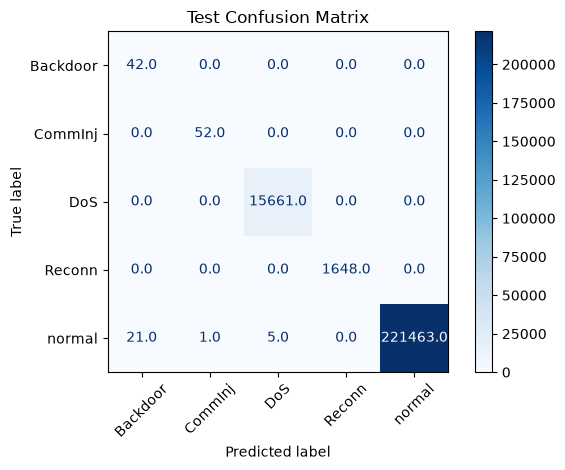

In [13]:
evaluate_model(best_clf, X_test, y_test, 'Test')

In [14]:
joblib.dump(best_clf, '../models/xgboost.joblib')

['../models/xgboost.joblib']